# In the Neighborhood: Revisiting kNN as a Tool for Movie Recommendation Systems 
### Group 5 - Ashley Bedford, Aida Hashemlou, and Luis Barriga
***
The following code is uesd to create and evaluate our kNN Movie Recommendation System Models in order to compare the different algorithms' performance results.

### Import Libraries

In [1]:
import pickle
import random
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

from statistics import mean
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import confusion_matrix, mean_squared_error, ConfusionMatrixDisplay
from scipy.sparse import csr_matrix

### Load the MovieLens 1OOK dataset

In [2]:
# Load our ratings and movies csv data
ratings_df = pd.read_csv("ratings.csv")
movies_df = pd.read_csv("movies.csv")

### Data Pre-processing

In [3]:
# Drop the timestamp column
ratings_df.drop(columns=['timestamp'])

# Filter the columns in both dataframes for what we need
movie2 = movies_df.loc[:, ["movieId", "title"]]
rating = ratings_df.loc[:, ["userId", "movieId", "rating"]]

# Join the movie and rating data tables into one bigger table
data = pd.merge(movie2, rating, on='movieId')
data = data.iloc[:1000000, :]

##### 1) Create 2 copies of a pivoted data frame to create unique input matrices for the kNN Model

In [4]:
# Create 2 copies of a pivoted data frame
merged_df = data.pivot_table(
    index=['title'],  
    columns=['userId'],
    values='rating',
    aggfunc='mean'
).fillna(0)

merged_df2 = data.pivot_table(
    index=['title'],  
    columns=['userId'],
    values='rating',
    aggfunc='mean'
).fillna(0)

##### 2) We will need to reset the indices of the second pivoted dataframe in order to access the row values of our movies in the evaluation portion

In [5]:
# Reset the indices of the second pivoted data frame
merged_df2 = merged_df2.reset_index()

##### 3) Convert dataframe of movie features to a CSR Matrix using the scipy.sparse library
In creating our recommendation system, we loaded our data and converted it into a 2-Dimensional CSR Matrix of users and movies. This will serve as the input for our kNN Model. Converting our input data to a CSR (Compressed Sparse Row) Matrix allows us to compute similarity measures between users or items in an efficient way. This format is great for representing sparse matrices, where the majority of the entries are zero. 

In our recommendations system, the CSR Matrix typically represents the user-item interactions. For example, to compute the similarity between two users, the kNN algorithm only needs to consider the non-zero entries in the CSR Matrix for those two users, rather than iterating over every possible pair of items, which saves time when using large datasets. Additionally, using this format can reduce the memory required to store the user-item interactions, making it easier for us to run larger datasets with limited resources.

In [6]:
# Convert our first pivoted table into a csr matrix
movie_matrix = csr_matrix(merged_df.values)

### Create 4 kNN Models for Evaluation
The following distance metrics are used in each unique kNN Model to be evaluated:
* <b>Euclidean</b>: A distance metric that calculates the straight-line distance between two points in a multidimensional space. It is commonly used in kNN classification to determine the similarity between data points.<br>
* <b>Cosine</b>: A distance metric that measures the cosine of the angle between two vectors. It is commonly used in kNN classification to determine the similarity between text documents or other high-dimensional data.<br>
* <b>Minkowski</b>: A distance metric that generalizes both Euclidean and Manhattan distance by allowing for a variable exponent parameter. It is commonly used in kNN classification when different dimensions have different scales or units.<br>
* <b>Manhattan</b>: A distance metric that calculates the distance between two points by summing the absolute differences between their corresponding coordinates. It is commonly used in kNN classification when different dimensions have different units or scales and the actual distance between points is not relevant.

In [7]:
# Set k as the number of similar movies to recommend
k = 10

# Create 4 kNN Models using the k value
knn = knn_euc = NearestNeighbors(n_neighbors=k, leaf_size=100, metric="euclidean", algorithm='auto')
knn_cos = NearestNeighbors(n_neighbors=k, leaf_size=100, metric="cosine", algorithm='auto')
knn_mink = NearestNeighbors(n_neighbors=k, leaf_size=100, metric="minkowski", algorithm='auto')
knn_manhattan = NearestNeighbors(n_neighbors=k, leaf_size=100, metric="manhattan", algorithm='auto')

### Fit & Store all Models
We will fit each of our 4 models to the movie matrix. This will allow us prepare our models with the data necessary to make recommendations that we can evaluate.

In [8]:
# Fit the Euclidean Model to our training data
knn.fit(movie_matrix)

# Create a new file to store the model in
knnPickle = open('knnpickle_file_au_eu', 'wb')

# Specify the source and destination
pickle.dump(knn, knnPickle)

# Close the file
knnPickle.close()

# Fit the Cosine Model to our training data
knn_cos.fit(movie_matrix)

# Create a new file to store the model in
knnPickle = open('knnpickle_file_au_cs', 'wb')

# Specify the source and destination
pickle.dump(knn, knnPickle)

# Close the file
knnPickle.close()

# Fit the Minkowski Model to our training data
knn_mink.fit(movie_matrix)

# Create a new file to store the model in
knnPickle = open('knnpickle_file_au_mk', 'wb')

# Specify the source and destination
pickle.dump(knn_mink, knnPickle)

# Close the file
knnPickle.close()

# Fit the Matthattan Model to our training data
knn_manhattan.fit(movie_matrix)

# Create a new file to store the model in
knnPickle = open('knnpickle_file_au_mt', 'wb')

# Specify the source and destination
pickle.dump(knn_manhattan, knnPickle)

# Close the file
knnPickle.close()

### Model Evaluation
How do we know our recommendations were good? We will not know that with 100% certainty, so we need to make a prediction on how well we think the user will like our recommendations. 

We did that using a <b>Modified Pearson Correlation Based Similarity with a Fixed Rating Threshold Algorithm</b> which entails taking the average actual high movie ratings of the user as an ‘actual_rating’ variable and comparing it to the average of all ratings for all recommended movies output by our KNN Model as a ‘predicted_rating’ variable. The threshold portion of our algorithm set a rating limit for only considering using user ratings of 3 or above as our input.

Please note that this approach will limit our confusion matrix values to only true positive and false negative values since kNN does not have a built-in way to handle negative values. We recommend finding a method to avoid recommending negative values and evaluate against them. This would make accuracy and recall the main evaluation metrics to compare the models against eachother. I have provided the formulas for precision and F1 Score, so that future work can be done against those 2 evaluation metrics once an approach for handling negative ratings are discovered.

In [9]:
# Create empty lists to store our evaluation metric values in
accuracy = []
precision = []
recall = []
f1_score = []

# Store all of our movie matrix column indices in an array
col_arr = movie_matrix.tocoo().col

##### Below is our evaluation method that can be used against all 4 models

In [10]:
def evaluation_method(my_model, eval_name):
   
    # Create lists to tally our evaluation metric results
    true_positives_ls = []
    false_positives_ls = []
    false_negatives_ls = []
    true_negatives_ls = []
    y_actual = []
    y_pred = []
    
    # Iterate through each user in the movie matrix
    for x in range(0, movie_matrix.shape[1]):  
        
        col_ind = col_arr[x]  # store the current column index
        curr_userId = int(merged_df.columns[col_ind-1])  # store the current userId
        
        # Create copies of our merged data frame
        my_df = merged_df.copy()
        my_df2 = merged_df2.copy()
        my_df3 = merged_df.copy()
        
        # Create an empty list to store our actual user 
        # ratings at or over our rating threshold of 3
        # Also, create a variable for our actual rating value
        actual_rating_ls = []
        actual_rating = 0
        
        # Iterate through my_df dataframe columns
        for idx, col in enumerate(my_df.columns):
            
            # IF this is not the current user we are evaluating
            # Set all of our input matrix values in that column to 0
            if x != idx: 
                my_df[col].values[:] = 0
            # ELSE Keep movie rows that the user being evaluated 
            # has rated the cooresponding movie 3 or higher
            else:  
                # This returns the row indexes of all rated movies
                # in order to prevent our recommendation system from
                # returning movies that the user has already seen and rated
                ans = my_df2.index[(my_df2[col] > 0).values].tolist()  
                
                # This returns the row indexes of all +3 rated movies
                # so that we can leave those cooresponding row values as they are
                ans2 = my_df2.index[(my_df2[col] >= 3).values].tolist() 
                
                # Any value in our user's column that is  
                # a less than 3 rating will be set to 0
                my_df.loc[my_df[col] < 3, col] = 0
                
                # Store all of our actual user ratings  
                # above 3 into our actual_rating list
                actual_rating_ls = my_df[col].values
                actual_rating_ls = actual_rating_ls.tolist()
                
                # IF We will skip any user that only has negative 
                # ratings or no ratings for equal evaluation
                if set(actual_rating_ls) == {0}:
                    break
                    
                # ELSE Only keep the non-zero values to not skew our 
                # results towards zero and return the average 
                # positive rating of the user we are evaluating
                else:
                    actual_rating_ls = [i for i in actual_rating_ls if i != 0]
                    actual_rating = mean(actual_rating_ls)
        
        # We will skip any user that only has negative 
        # ratings or no ratings for equal evaluation           
        if set(actual_rating_ls) == {0}:
            break

        # Iterate through our dataframe's rows 
        # in order to expose the full rows of 
        # values more than 3 for the user against 
        # the rated movies only
        for idx, row in my_df2.iterrows():
            
            # If the row index is in our ans2 list, 
            # we will keep the values the same
            if idx in ans2:
                continue
                
            # ELSE change the row's values to 0
            else:  
                my_df3.iloc[idx,:] = 0

        # With our completed inout matrix, we will use 
        # it on the model to be evaluated and retrieve 
        # our distances and indices
        distances, indices = my_model.kneighbors(my_df3, n_neighbors=k)

        # Define an empty movie list to hold our recommendations
        movie_ls = []

        # Retrieve all of our recommendations and store them into the movie list
        movie_ls = indices.flatten()[:97190].tolist()
        set_movie_ls = set(movie_ls)

        # Create an empty list to hold all of our prediction values
        pred_rating_list = []

        # Iterate through our movie set list to extract our 
        # recommendations' actual movie ratings and 
        for movie_ind in set_movie_ls:
            # Calulate the average of all the recommendations' 
            # movie ratings and store it in our predicted rating list
            pred_rating_list.append(ratings_df[ratings_df['movieId'] == movie_ind]['rating'].mean())
            
            # Only calculate the average if there are values to calculate against
            if len(pred_rating_list) == 0:
                pred_rating_list.append(0)

        # Drop all NaNs from pred list
        pred_rating_list = [x for x in pred_rating_list if str(x) != 'nan']
        
        # Calculate our final predicted rating by 
        # taking the average of all predicted ratings
        predicted_rating = mean(pred_rating_list)

        # Create variables to tally our evaluation metric results
        true_positives = 0
        false_positives = 0
        false_negatives = 0
        true_negatives = 0

        # Calculate our Confusion Matrix Values
        if (actual_rating >= 3) & (predicted_rating >= 3):
            true_positives += 1
            true_positives_ls.append(1)
            y_actual.append(1)
            y_pred.append(1)
        elif (actual_rating < 3) & (predicted_rating >= 3):
            false_positives += 1
            false_positives_ls.append(1)
            y_actual.append(0)
            y_pred.append(1)
        elif (actual_rating >= 3) & (predicted_rating < 3):
            false_negatives += 1
            false_negatives_ls.append(1)
            y_actual.append(1)
            y_pred.append(0)
        else:
            true_negatives += 1
            true_negatives_ls.append(1)
            y_actual.append(0)
            y_pred.append(0)

        acc = true_positives / (true_positives + false_positives + false_negatives + true_negatives) if (true_positives + false_positives) > 0 else 0
        accuracy.append(acc)

        pre = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        precision.append(pre)

        rec = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
        recall.append(rec)

        f1 = (2 * (precision[-1] * recall[-1]) / (precision[-1] + recall[-1])) if (precision[-1] + recall[-1]) > 0 else 0
        f1_score.append(f1)

    mean_accuracy = np.mean(accuracy)
    mean_precision = np.mean(precision)
    mean_recall = np.mean(recall)
    mean_f1_score = np.mean(f1_score)

    # Print our Evaluation Metric Results
    print(eval_name + " Evaluation Metric Results")
    print()
    print("Mean Accuracy: ", mean_accuracy)
    print("Mean Precision: ", mean_precision)
    print("Mean Recall: ", mean_recall)
    print("Mean F1 Score: ", mean_f1_score)

    print()
    print("TP: ", sum(true_positives_ls))
    print("FP: ", sum(false_positives_ls))
    print("TN: ", sum(true_negatives_ls))
    print("FN: ", sum(false_negatives_ls))
    
    # Clear all outside lists for reuse
    accuracy.clear()
    precision.clear()
    recall.clear()
    f1_score.clear()
    
    # Return the values needed to create our Confusion Matrix
    return(y_actual, y_pred)
                                        

##### Run our evaluation against our 4 Models
Let's define the metrics that we will use to compare our models to eachother with.
* Accuracy: The percent of correct predictions made over all the predictions made. This is calculated as (true_positives / (true_positives + false_positives + false_negatives + true_negatives)).
* Recall: The percent of correctly identified positive cases. This is calculated as (true_positives / (true_positives + false_negatives))

### 1) Euclidean Distance
As we can see below, we have an Accuracy and Recall of 100%. 
* <b>True Positives</b>: All actual ratings that were evaluated were 3 or higher and we predicted that the user would rate our recommended movies 3 or higher across 437 users.

<b>This shows that using the Euclidean Distance kNN Model would result in our recommendations on average being liked and rated highly by the users. These are strong results. Let's see the other distance kNN models will perform against it.</b>

In [11]:
y_actual, y_pred = evaluation_method(knn, "Euclidean Distance")

Euclidean Distance Evaluation Metric Results

Mean Accuracy:  1.0
Mean Precision:  1.0
Mean Recall:  1.0
Mean F1 Score:  1.0

TP:  441
FP:  0
TN:  0
FN:  0


##### Create Confusion Matrix

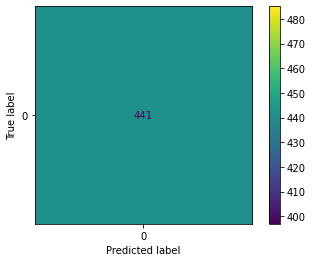

In [18]:
# Define the Confusion Matrix Variable
cm = confusion_matrix(y_actual, y_pred)
    
# Plot the Confusion Matrix
my_plot = ConfusionMatrixDisplay(confusion_matrix=cm)
my_plot.plot()
plt.show()

### 2) Cosine Similarity
As we can see below, we have an Accuracy and Recall of 99%. 
* <b>True Positives</b>: All actual ratings that were evaluated were 3 or higher and we predicted that the user would rate our recommended movies 3 or higher across 437 users. 
* <b>False Negatives</b>: All actual ratings that were evaluated were 3 or higher and we predicted that the user would rate our recommended movies less than 3 across 4 users. 

<b>This shows that using the Cosine Similarity kNN Model would result in our recommendations on average being liked and rated highly by the users; however, it did not perform as strongly as the Euclidean Distance kNN Model.</b>

In [19]:
y_actual, y_pred = evaluation_method(knn_cos, "Cosine")

Cosine Evaluation Metric Results

Mean Accuracy:  0.9909297052154195
Mean Precision:  0.9909297052154195
Mean Recall:  0.9909297052154195
Mean F1 Score:  0.9909297052154195

TP:  437
FP:  0
TN:  0
FN:  4


##### Create Confusion Matrix

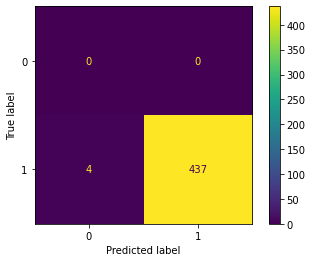

In [21]:
# Define the Confusion Matrix Variable
cm = confusion_matrix(y_actual, y_pred)
    
# Plot the Confusion Matrix
my_plot = ConfusionMatrixDisplay(confusion_matrix=cm)
my_plot.plot()
plt.show()

### 3) Minkowski Distance
As we can see below, we have an Accuracy and Recall of 100%. 
* <b>True Positives</b>: All actual ratings that were evaluated were 3 or higher and we predicted that the user would rate our recommended movies 3 or higher across 441 users.

<b>This shows that using the Minkowski Distance kNN Model would result in our recommendations on average being liked and rated highly by the users. These are strong results. It produced the same results as the Euclidean Distance kNN Model.</b>

In [22]:
y_actual, y_pred = evaluation_method(knn_mink, "Minkowski")

Minkowski Evaluation Metric Results

Mean Accuracy:  1.0
Mean Precision:  1.0
Mean Recall:  1.0
Mean F1 Score:  1.0

TP:  441
FP:  0
TN:  0
FN:  0


##### Create Confusion Matrix

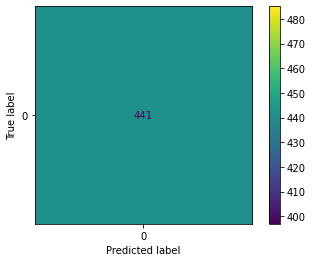

In [24]:
# Define the Confusion Matrix Variable
cm = confusion_matrix(y_actual, y_pred)
    
# Plot the Confusion Matrix
my_plot = ConfusionMatrixDisplay(confusion_matrix=cm)
my_plot.plot()
plt.show()

### 4) Manhattan Distance
As we can see below, we have an Accuracy and Recall of 100%. 
* <b>True Positives</b>: All actual ratings that were evaluated were 3 or higher and we predicted that the user would rate our recommended movies 3 or higher across 441 users.

<b>This shows that using the Minkowski Distance kNN Model would result in our recommendations on average being liked and rated highly by the users. These are strong results. It produced the same results to the Euclidean Distance and Manhattan Distance kNN Models.</b>

In [25]:
y_actual, y_pred = evaluation_method(knn_manhattan, "Manhattan")

Manhattan Evaluation Metric Results

Mean Accuracy:  1.0
Mean Precision:  1.0
Mean Recall:  1.0
Mean F1 Score:  1.0

TP:  441
FP:  0
TN:  0
FN:  0


##### Create Confusion Matrix

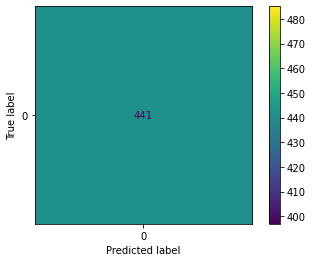

In [26]:
# Define the Confusion Matrix Variable
cm = confusion_matrix(y_actual, y_pred)
    
# Plot the Confusion Matrix
my_plot = ConfusionMatrixDisplay(confusion_matrix=cm)
my_plot.plot()
plt.show()

### Final Results

* The <b>Euclidean, Manhattan, and Minkowski Distance kNN Models</b> performed the best when compared to all 4 models. They produced a high rates of accuracy and recall. They also evaluated the most users accurately.

* The <b>Cosine Similarity kNN Model</b> performed the next best since the a small subset of users had inaccurate prediction values when compared to the above 3 models. Regardless of this finding, the accuracy and recall rate was high but slightly lower than the 3 models above.

* Since the task of this recommendation system was to figure out which model would be the best to accurately provide movie recommendations to the user, based on the results above, using the <b>Euclidean, Manhattan, and Minkowski Distance Metrics</b> are the best choices. 